
# Assignment 2 #

## Import Libraries: ##

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

Now read from the dataset:

In [3]:
dt = pd.read_csv('C:/Users/Katlego/Downloads/survivors.csv')

dt.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Descriptive statistics ##

In [4]:
dt.shape

dt.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
dt.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## Handling missing values ##

In [6]:
dt.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
missing_values = dt.isnull().sum().sort_values(ascending = False)
percentage_missing_values = (missing_values/len(dt))*100
pd.concat([missing_values, percentage_missing_values], axis = 1, keys= ['Missing values', '% Missing'])

,Missing values,% Missing
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


There is a large amount of missing values in the **Cabin** column, so we drop it along with the **Ticket** column. We also replace the missing ages with the median age in the **Age** column where there are missing values.

Also we separate the **Embarked** column into three columns for each destination.

In [8]:
dt.drop(columns=['Cabin','Ticket'], inplace=True)

dt['Age'] = dt['Age'].fillna(dt['Age'].median())
dt['Age'] = dt['Age'].astype(int)

dt['Embarked'].unique()
dt['Embarked'] = dt['Embarked'].astype('category')
dt['Embarked'] = dt['Embarked'].cat.set_categories(['C', 'Q', 'S'])
dt = pd.get_dummies(dt, columns=['Embarked'])

dt.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,7.2500,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,71.2833,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,8.0500,False,False,True


# Clean the data, And convert non-numerical values to numerical values #

In [9]:
le =LabelEncoder()

dt['Embarked_C']=le.fit_transform(dt['Embarked_C'])
dt['Embarked_Q']=le.fit_transform(dt['Embarked_Q'])
dt['Embarked_S']=le.fit_transform(dt['Embarked_S'])
dt['Sex']=le.fit_transform(dt['Sex'])

dt.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35,0,0,8.0500,0,0,1


## Histogram for the Passengers age groups ##

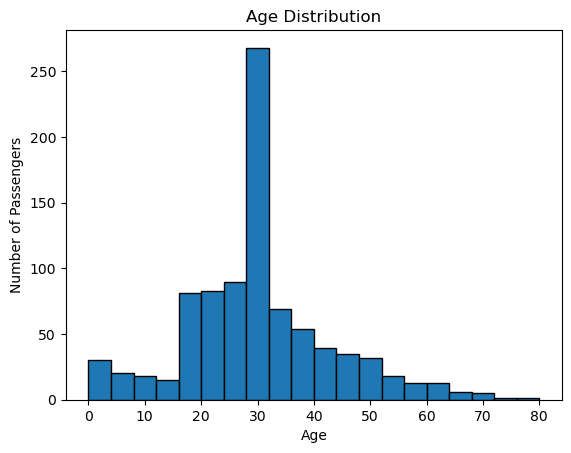

In [10]:
plt.hist(dt['Age'].dropna(), bins=20,edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

There was a high frequency of people between the ages 20-40.There is also a small peak for children aged 0–5, indicating a significant number of infants. Conversely, passengers over the age of 70 were very rare, representing the lowest portion of the population onboard.

## Bar chat for passenger vs Age ##

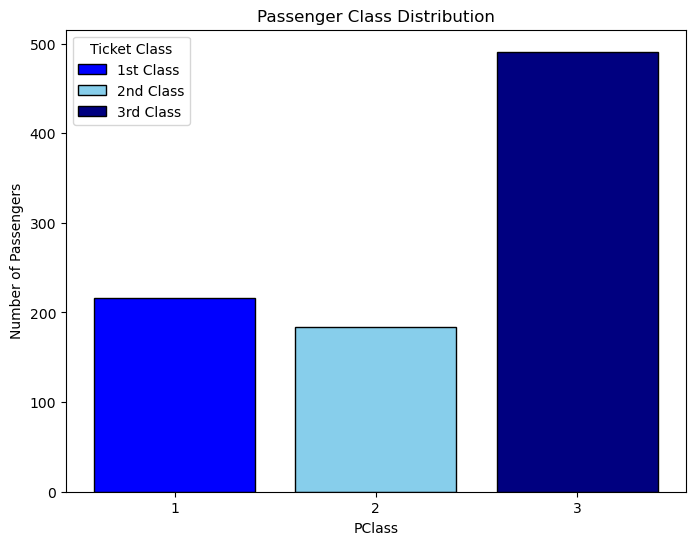

In [12]:
classes = ['1st Class', '2nd Class', '3rd Class']
counts = dt['Pclass'].value_counts().sort_index()
colors = ['blue', 'skyblue', 'navy']

# Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.index.astype(str), counts.values,color=colors, edgecolor='black')

plt.legend(bars, classes, title="Ticket Class")

plt.title('Passenger Class Distribution')
plt.xlabel('PClass')
plt.ylabel('Number of Passengers')
plt.show()

There is a high frequency of passengers in the 3rd class, followed by the 1st and 2nd class. Over 450 passengers are in the 3rd class, which is more than both 1st and 2nd classes combined. This indicates why a high number of deaths occured in this category.

## Heatmap for the survival rate due to sex ##

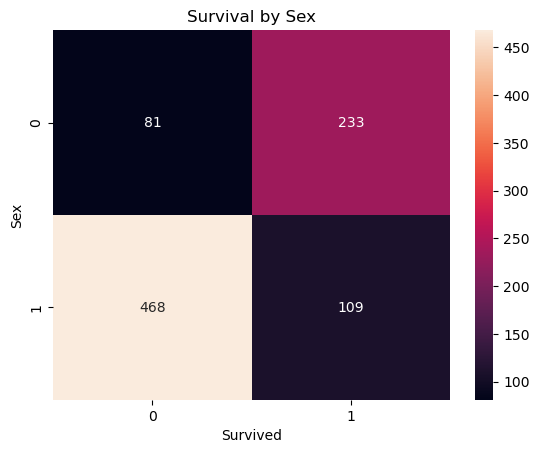

In [13]:
sex_survival = pd.crosstab(dt['Sex'], dt['Survived'])

sns.heatmap(sex_survival, annot=True, fmt='d')
plt.title("Survival by Sex")
plt.show()

## Heatmap for the survival rate due to class ##

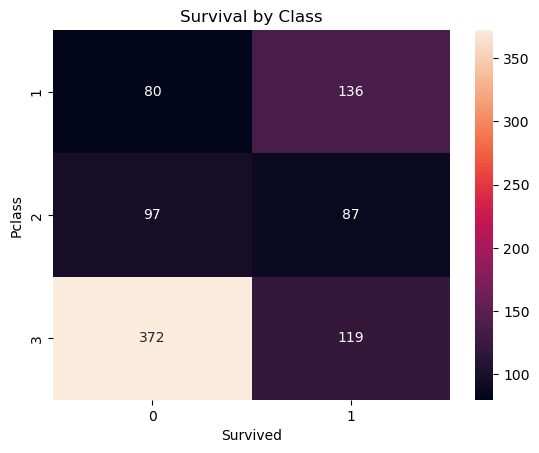

In [14]:
pclass_survival = pd.crosstab(dt['Pclass'], dt['Survived'])

sns.heatmap(pclass_survival, annot=True, fmt='d')
plt.title("Survival by Class")
plt.show()

## Heatmap for the survival rate across Sex and Passenger class ##

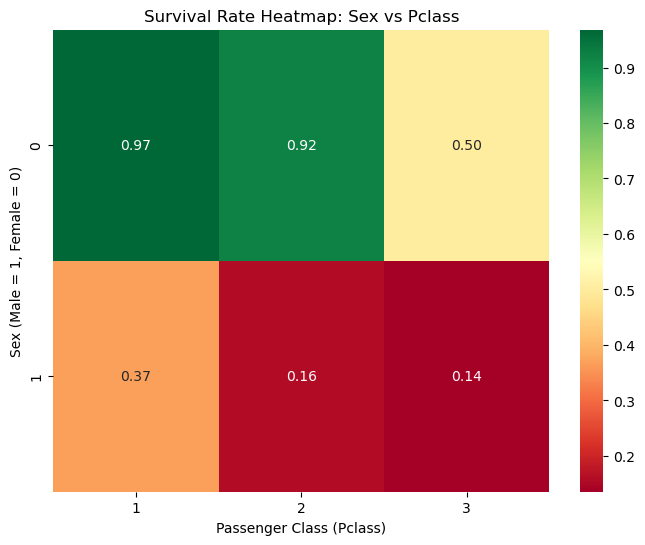

In [15]:
survival_pivot = dt.pivot_table(values='Survived', index='Sex', columns='Pclass')

plt.figure(figsize=(8, 6))
sns.heatmap(survival_pivot, annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('Survival Rate Heatmap: Sex vs Pclass')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Sex (Male = 1, Female = 0)')
plt.show()



The heatmap reveals a strong correlation between survival, gender, and ticket class.

1. ***First class:*** 97% of the females survived in this class while 37% of males survied, showcasing that females had the highest survival in this class
2. **Second class:** 92% of the females survived in this class while 16% of the males survived, a lower percentage than the first class.
3. ***Third class:*** 50% of the females survived in this class while 14% of the males survived. even lower than the second class.

Compared to females, the males had the lowest chance of survivals as you go down from first class, while females survival rate was higher in the first and second class, it dropped as well in 3rd class, it appears that the males had the highest chance of survival in the first class compared to the 3rd class. This is also true for females as well.

## Scatter plot for  Age vs Fare ##

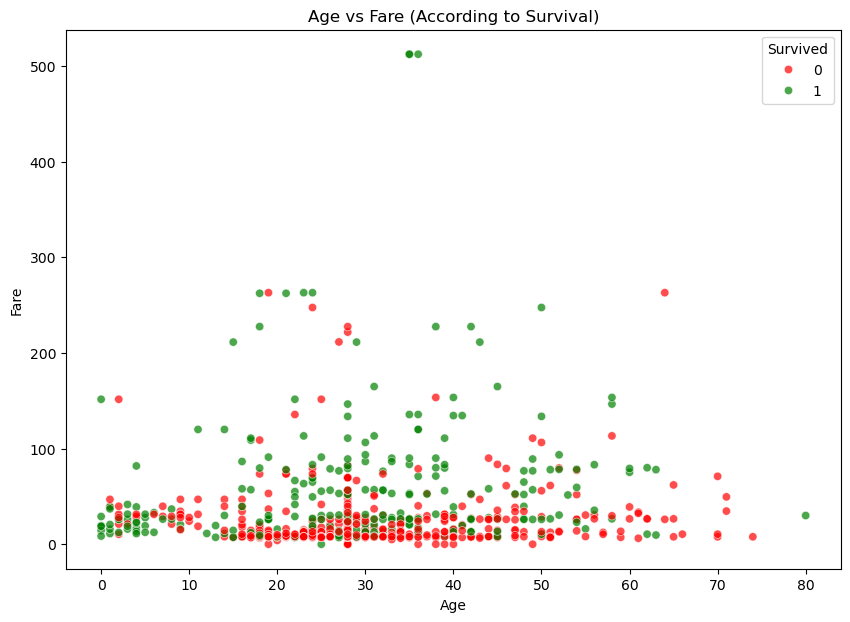

In [16]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x='Age', y='Fare', hue='Survived', data=dt, palette={0: 'red', 1: 'green'}, alpha=0.7)

plt.title("Age vs Fare (According to Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## Pie Chart for survival by gender ##

Text(0.5, 1.0, 'Male Survival Rate')

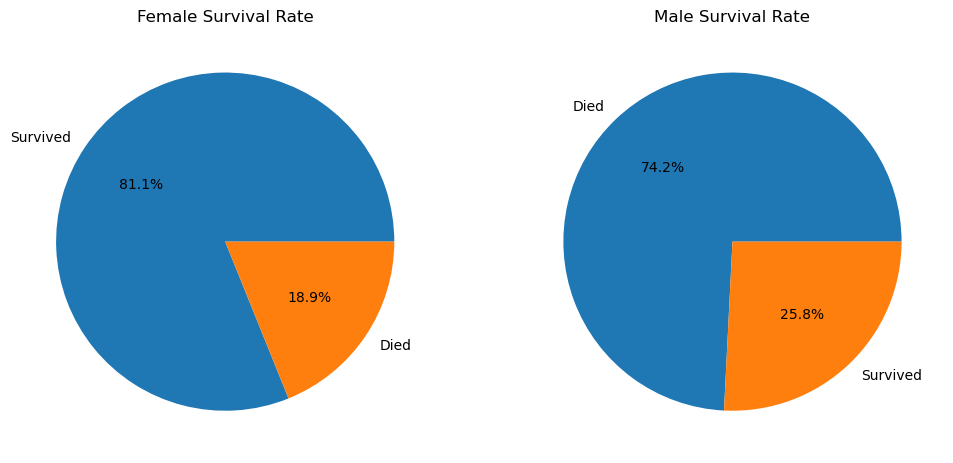

In [17]:

female_survived = dt[dt['Sex'] == 1]['Survived'].value_counts()
male_survived = dt[dt['Sex'] == 0]['Survived'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(female_survived, labels=['Survived', 'Died'], autopct='%1.1f%%')
ax1.set_title('Female Survival Rate')

ax2.pie(male_survived, labels=['Died', 'Survived'], autopct='%1.1f%%')
ax2.set_title('Male Survival Rate')

 Between both male and females, a high percentage of females survvived as compared to males

## Pie chart for survival by class ##

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


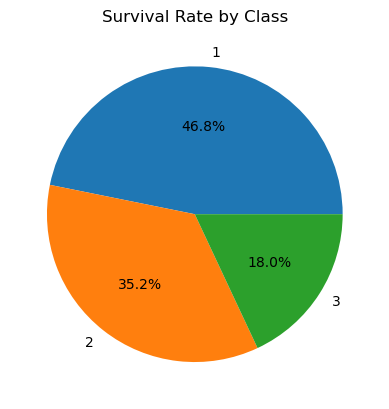

In [18]:
class_survival_rate = dt.groupby('Pclass')['Survived'].mean()
print(class_survival_rate)

class_survival_rate.plot(kind='pie', autopct='%1.1f%%')
plt.title("Survival Rate by Class")
plt.ylabel("")
plt.show()

A large percentage of passengers from the first class survived as compared to the other classes, class 2 came in second place ,whereas the third class had fewer survivors. 

## Additional features ##

In [21]:
dt['Title'] = dt['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)

dt['Title'] = dt['Title'].replace(['Ms', 'Mlle'], 'Miss')
dt['Title'] = dt['Title'].replace(['Mme'], 'Mrs')
dt['Title'] = dt['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)

print(dt['Title'].value_counts())

Title
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64


In [22]:
le = LabelEncoder()
dt['Title']=le.fit_transform(dt['Title'])

dt[['Name','Title']].head()

,Name,Title
0,"Braund, Mr. Owen Harris",2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",3
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",3
4,"Allen, Mr. William Henry",2


In [23]:
dt['FamilySize']=dt['SibSp']+dt['Parch']+1
dt.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,7.2500,0,0,1,2,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,71.2833,1,0,0,3,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,7.9250,0,0,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,53.1000,0,0,1,3,2
4,5,0,3,"Allen, Mr. William Henry",1,35,0,0,8.0500,0,0,1,2,1


By the look of things we don't require the **Name** column so:

In [24]:
dt.drop(['Name'],axis=1,inplace=True)
dt.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title,FamilySize
0,1,0,3,1,22,1,0,7.2500,0,0,1,2,2
1,2,1,1,0,38,1,0,71.2833,1,0,0,3,2
2,3,1,3,0,26,0,0,7.9250,0,0,1,1,1
3,4,1,1,0,35,1,0,53.1000,0,0,1,3,2
4,5,0,3,1,35,0,0,8.0500,0,0,1,2,1


## Outliers and Correlation ##

In [25]:
median_age=dt['Age'].median()

print('Our mean age for the dataset of survivors is: ',median_age)

Our mean age for the dataset of survivors is:  28.0


## Mean age for both male and female survivors ##

In [26]:
stats=dt.groupby(['Sex','Pclass'])['Age'].mean()
print(stats)

Sex  Pclass
0    1         33.978723
     2         28.697368
     3         23.555556
1    1         38.983607
     2         30.481481
     3         26.893372
Name: Age, dtype: float64


## Variance for both male and female survivors ##

In [27]:
stats=dt.groupby(['Sex','Pclass'])['Age'].var()
print(stats)

Sex  Pclass
0    1         171.182338
     2         161.253860
     3         123.087801
1    1         215.305514
     2         202.270682
     3         107.852759
Name: Age, dtype: float64


## standard deviation for both male and female survivors ##

In [28]:
stats=dt.groupby(['Sex','Pclass'])['Age'].std()
print(stats)

Sex  Pclass
0    1         13.083667
     2         12.698577
     3         11.094494
1    1         14.673293
     2         14.222190
     3         10.385218
Name: Age, dtype: float64


## Outliers ##

In [29]:
Q1 = dt['Age'].quantile(0.25)
Q3 = dt['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dt[(dt['Age'] < lower_bound) | (dt['Age'] > upper_bound)]
print(outliers)

     PassengerId  Survived  Pclass  Sex  Age  SibSp  Parch     Fare  \
7              8         0       3    1    2      3      1  21.0750   
11            12         1       1    0   58      0      0  26.5500   
15            16         1       2    0   55      0      0  16.0000   
16            17         0       3    1    2      4      1  29.1250   
33            34         0       2    1   66      0      0  10.5000   
..           ...       ...     ...  ...  ...    ...    ...      ...   
827          828         1       2    1    1      0      2  37.0042   
829          830         1       1    0   62      0      0  80.0000   
831          832         1       2    1    0      1      1  18.7500   
851          852         0       3    1   74      0      0   7.7750   
879          880         1       1    0   56      0      1  83.1583   

     Embarked_C  Embarked_Q  Embarked_S  Title  FamilySize  
7             0           0           1      0           5  
11            0          

In [30]:
# Mean with all data (including outliers)
mean_with_outliers = dt['Age'].mean()


med_age = dt['Age'].median()
upper_limit = med_age + 35
lower_limit = med_age - 15

# Filter the data (Removing the outliers)
cleaned_data = dt[(dt['Age'] <= upper_limit) & (dt['Age'] >= lower_limit)]
mean_without_outliers = cleaned_data['Age'].mean()

#  Calculating the Difference
difference = mean_with_outliers - mean_without_outliers

print(f"Mean with Outliers: {mean_with_outliers}")
print(f"Mean without Outliers: {mean_without_outliers}")
print(f"The 'Pull' of Outliers: {difference}")

Mean with Outliers: 29.34567901234568
Mean without Outliers: 30.81334981458591
The 'Pull' of Outliers: -1.467670802240228


In [34]:
dt.to_csv('clean_survivors.csv', index=False)